# 01. EDA. Прогноз оттока

**Данные:** [Kaggle: IBM HR Analytics](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) (1470×35, целевой признак `Attrition`)

**Метрики:** дисбаланс классов (~16% ушедших) => важны **ROC-AUC** (качество ранжирования), **Recall** (не пропустить уходящих), **Precision** и **F1** (контроль ложных тревог)

In [1]:
import sys
from pathlib import Path

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for i in [here, *here.parents]:
        if (i / 'src' / 'config.py').is_file():
            return i
    raise FileNotFoundError()

ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
    
try:
    import numpy as np
    import pandas as pd
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
except ModuleNotFoundError as e:
    req = (ROOT / 'requirements.txt').resolve()
    raise RuntimeError() from None

from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
else:
    matplotlib.use('module://matplotlib_inline.backend_inline')

from src.config import DATA_RAW, RANDOM_STATE
from src.hypothesis_tests import ttest_income_by_attrition

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv(DATA_RAW)
raw_shape = df.shape
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
TARGET = 'Attrition'
info = {'rows': len(df), 'cols': df.shape[1], 'missing': int(df.isna().sum().sum()), 'dup_rows': int(df.duplicated().sum())}
low_var = [i for i in df.select_dtypes(exclude='object').columns if df[i].nunique() <= 1]
y_raw = (df[TARGET] == 'Yes').astype(int)
print('Attrition rate:', y_raw.mean().round(3), 'nunique<=1 (numeric):', low_var)

Attrition rate: 0.161 nunique<=1 (numeric): ['EmployeeCount', 'StandardHours']


In [4]:
info

{'rows': 1470, 'cols': 35, 'missing': 0, 'dup_rows': 0}

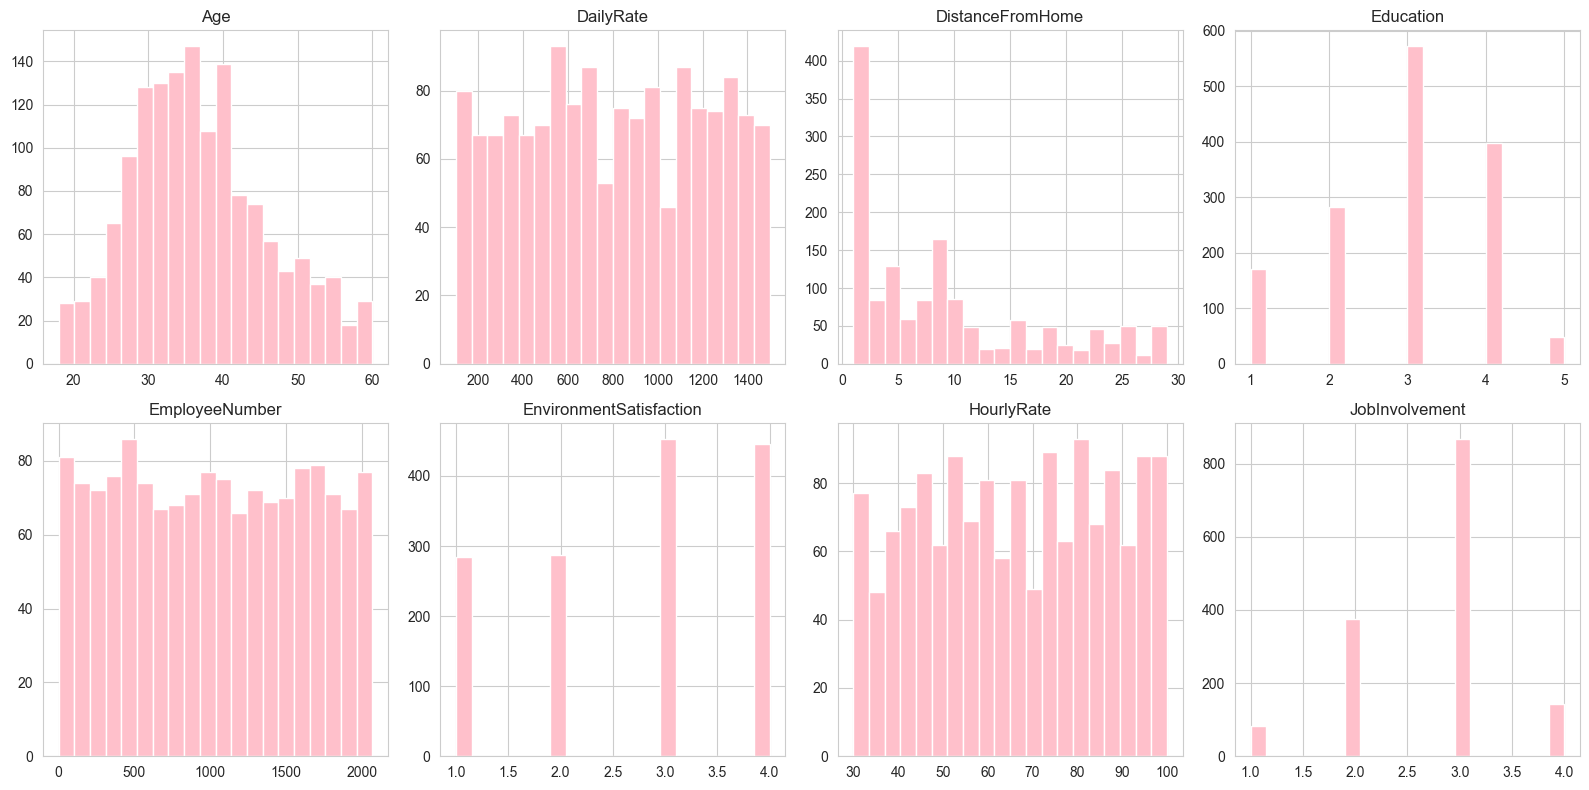

In [5]:
n_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'EmployeeCount' in n_cols:
    pass
n_show = [i for i in n_cols if i not in ('EmployeeCount','StandardHours')][:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, j in zip(axes.ravel(), n_show):
    df[j].hist(ax=i, bins=20, color='pink', edgecolor='white')
    i.set_title(j)
plt.tight_layout()
plt.show()

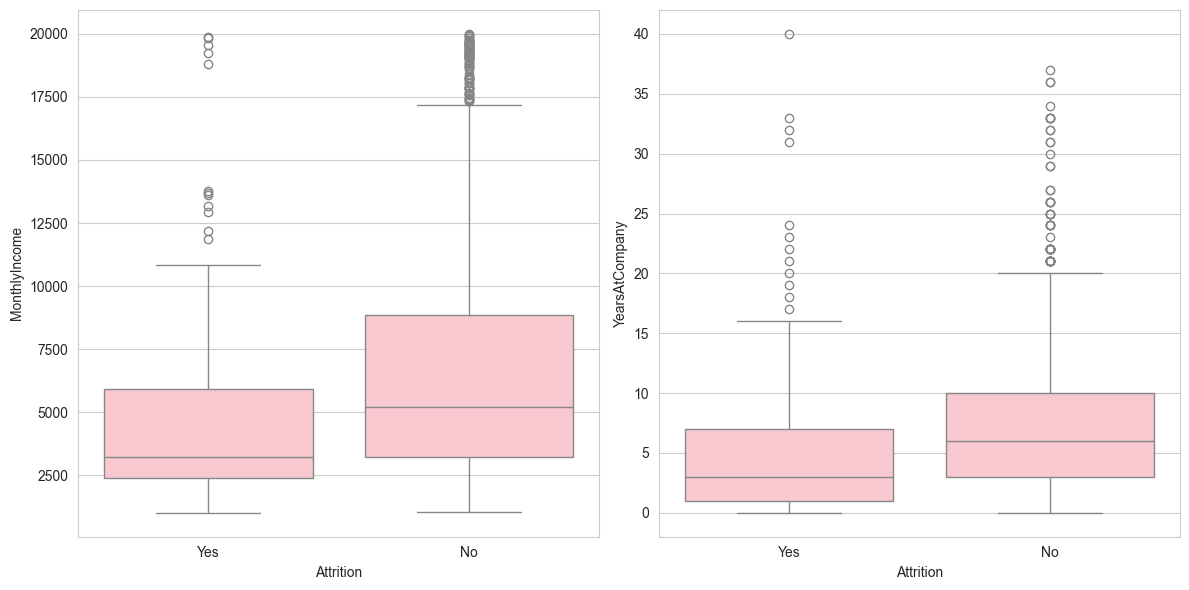

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(x=df[TARGET], y=df['MonthlyIncome'], ax=ax[0], color='pink')
sns.boxplot(x=df[TARGET], y=df['YearsAtCompany'], ax=ax[1], color='pink')
plt.tight_layout()
plt.show()

In [7]:
for i in ['OverTime', 'JobRole', 'BusinessTravel'][:3]:
    ct = pd.crosstab(df[i], y_raw, normalize='index')
    print(i)
    print(ct.round(2), '\n')

OverTime
Attrition     0     1
OverTime             
No         0.90  0.10
Yes        0.69  0.31 

JobRole
Attrition                     0     1
JobRole                              
Healthcare Representative  0.93  0.07
Human Resources            0.77  0.23
Laboratory Technician      0.76  0.24
Manager                    0.95  0.05
Manufacturing Director     0.93  0.07
Research Director          0.98  0.02
Research Scientist         0.84  0.16
Sales Executive            0.83  0.17
Sales Representative       0.60  0.40 

BusinessTravel
Attrition             0     1
BusinessTravel               
Non-Travel         0.92  0.08
Travel_Frequently  0.75  0.25
Travel_Rarely      0.85  0.15 



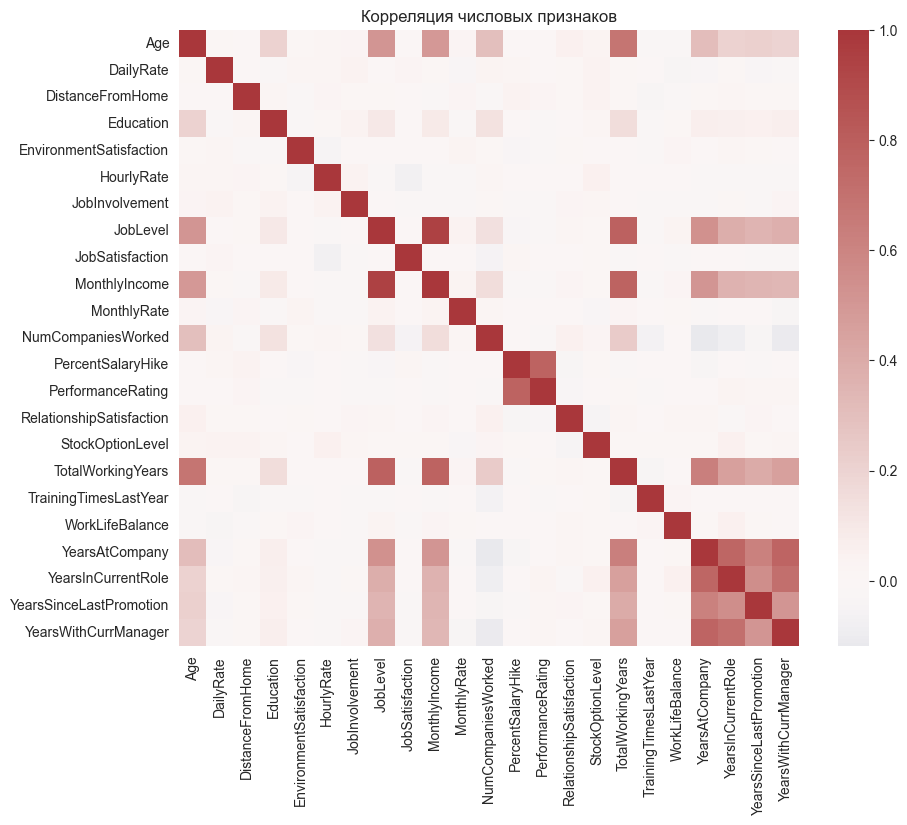

In [8]:
dropc = [i for i in ['EmployeeCount', 'StandardHours', 'EmployeeNumber'] if i in df.columns]
dfn = df.drop(columns=dropc, errors='ignore')
corr = dfn[dfn.select_dtypes(include=[np.number]).columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='vlag', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

In [9]:
z = df.copy()
z['Attr_01'] = (z[TARGET] == 'Yes').astype(int)

sub = z[['OverTime', 'Attr_01']]
ct = pd.crosstab(sub['OverTime'], sub['Attr_01'])
h1, p1, _, _ = stats.chi2_contingency(ct)
print('H1 (сверхурочные): chi2=%.2f, p=%.2e' % (h1, p1))

low_sat = (z['JobSatisfaction'] <= 2).astype(int)
ct2 = pd.crosstab(low_sat, z['Attr_01'])
h2, p2, _, _ = stats.chi2_contingency(ct2)
print('H2 (низкая удовлетворенность 1–2): chi2=%.2f, p=%.2e' % (h2, p2))

short = (z['YearsAtCompany'] < 3).astype(int)
ct3 = pd.crosstab(short, z['Attr_01'])
h3, p3, _, _ = stats.chi2_contingency(ct3)
print('H3 (стаж < 3 л.): chi2=%.2f, p=%.2e' % (h3, p3))

ct4 = pd.crosstab(z['BusinessTravel'], z['Attr_01'])
h4, p4, _, _ = stats.chi2_contingency(ct4)
print('H4 (командировки): chi2=%.2f, p=%.2e' % (h4, p4))

t_df = z[['MonthlyIncome', 'Attr_01']].rename(columns={'Attr_01': 'Attrition'})
t_stat, p_t, _ = ttest_income_by_attrition(t_df, 'MonthlyIncome', 'Attrition')
print('H5 (доход): Welch t p-value=%.2e' % p_t)


H1 (сверхурочные): chi2=87.56, p=8.16e-21
H2 (низкая удовлетворенность 1–2): chi2=8.28, p=4.00e-03
H3 (стаж < 3 л.): chi2=60.56, p=7.12e-15
H4 (командировки): chi2=24.18, p=5.61e-06
H5 (доход): Welch t p-value=4.43e-13
